In [2]:
from loguru import logger
logger.remove()
import sys
logger.add(sys.stderr, level="INFO")

import numpy as np
import pandas as pd
import xarray as xr
import torch
from pathlib import Path
import itertools

from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    context="paper",
    style="ticks",
    palette="Set2",
    rc={
        "figure.dpi": 600, "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "figure.labelsize": "small",
    },
)

from lib.models import DJModel
from lib.computation.statistics import cluster_correction
from lib.datasets import load_n_subjects, load_target_var, load_dataset
from lib.analyses.loaders import load_significant_times
from lib.analyses._plots import _plot_generalization, _plot_eigenspectrum
from bonner.caching import BONNER_CACHING_HOME
from bonner.computation.decomposition import PCA
from bonner.computation.metrics import covariance, pearson_r
from lib.computation.statistics import compute_p
from bonner.datasets.hebart2022_things_behavior import load_embeddings
from lib.datasets.hebart2022_things_behavior import sort_embeddings
from bonner.datasets.gifford2022_things_eeg_2 import load_metadata

# Import helper functions for memory-efficient loading
from lib._notebook_helpers import (
    get_scorer_kwargs,
    spearman_brown_correction,
    load_cvpca_dimensionality_streaming,
    add_time_markers,
)

In [2]:
# Common configuration
n_permutations = 1000

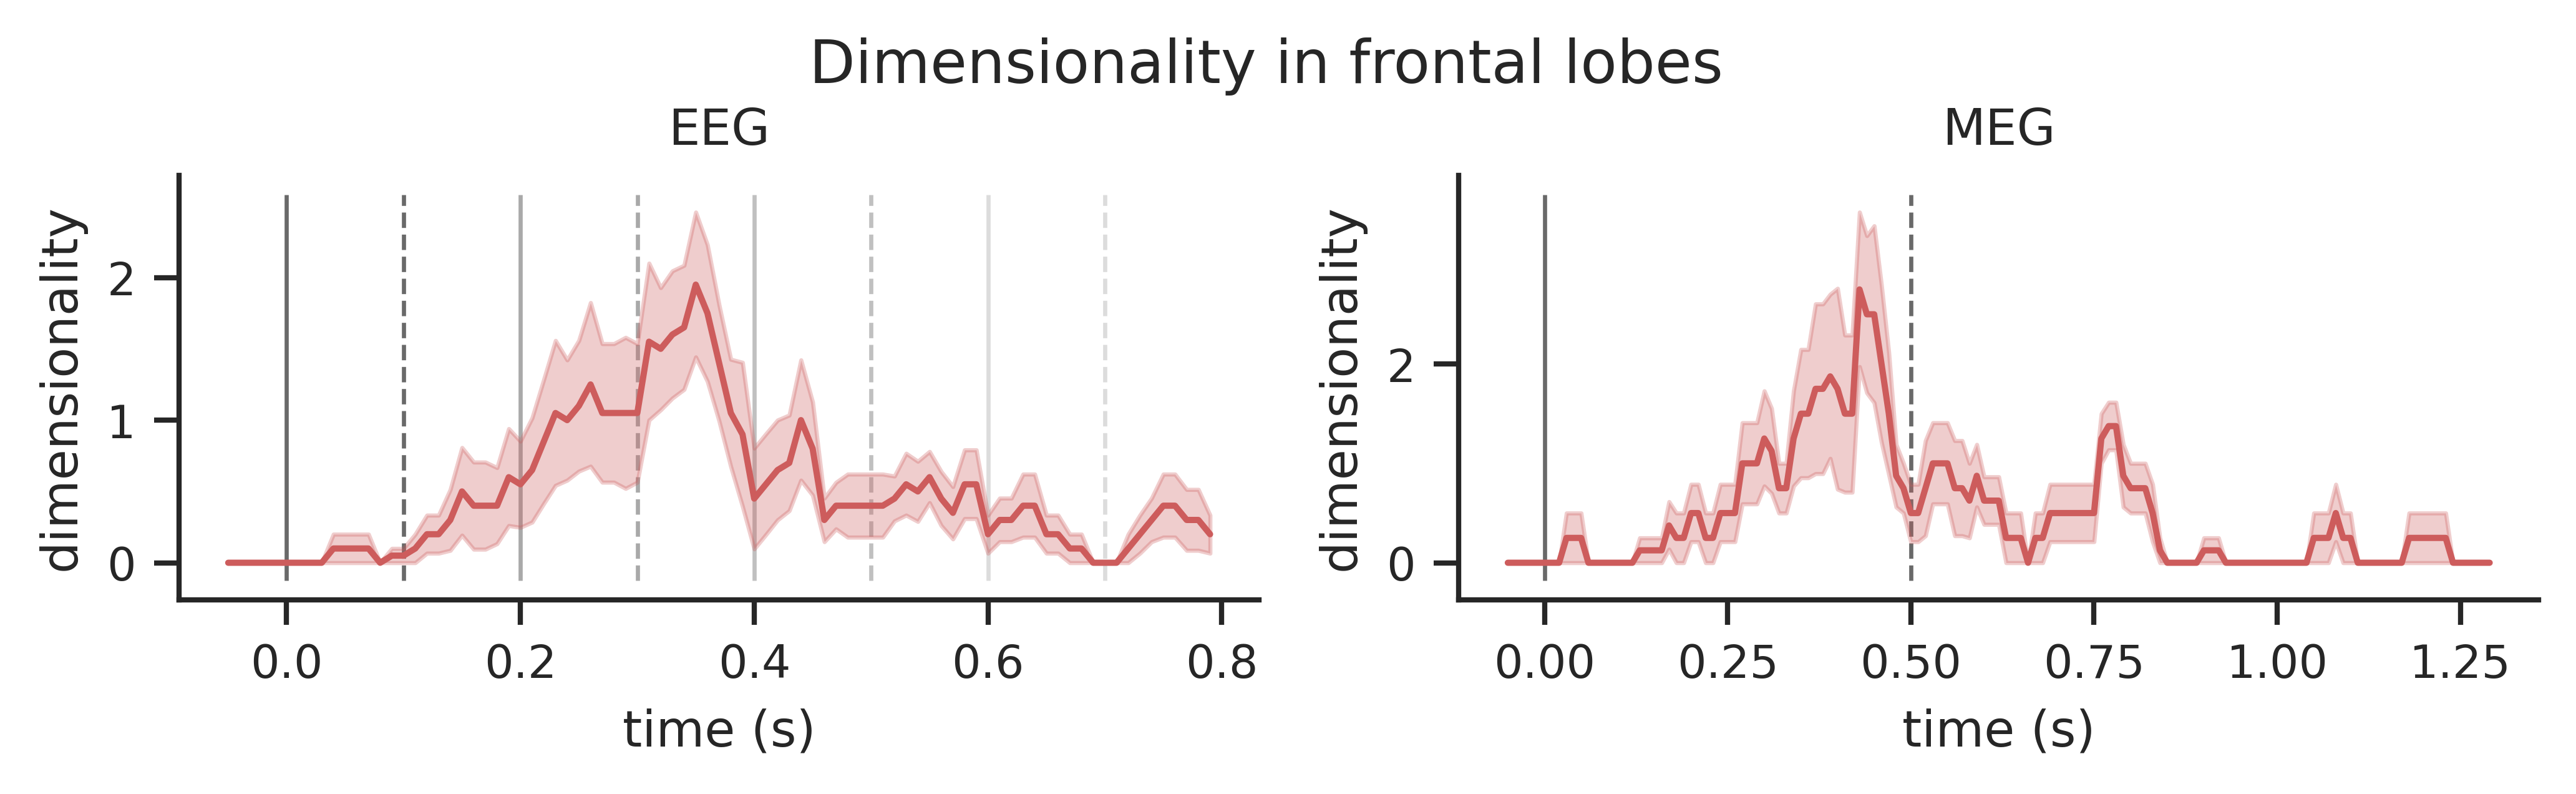

In [3]:
plt.close()
width_mm = 180
width_inches = width_mm / 25.4
height_inches = width_inches / 3.5
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, figsize=(width_inches, height_inches))

subjects = "all"
list_dim = "time"
folds = False

########## EEG dimensionality ##########
ax = axs[0]
ax.set_title("EEG")

dataset = "things_eeg_2"
load_dataset_kwargs = "rois=f"

cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
cdf = load_cvpca_dimensionality_streaming(cvpca_path, "EEG")

sns.lineplot(data=cdf, x="time", y="cvnsr", ax=ax, label="EEG dimensionality", color="indianred", errorbar=None, legend=False)
score = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").mean().values
err = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").sem().values
ax.fill_between(cdf.time.unique(), score-err, score+err, color="indianred", alpha=0.3)

ax.set(ylabel="dimensionality", xlabel="time (s)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ymin, ymax = ax.get_ylim()
add_time_markers(ax, dataset, ymin, ymax)

########## MEG dimensionality ##########
ax = axs[1]
ax.set_title("MEG")

dataset = "things_meg"
load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=f"

cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
cdf = load_cvpca_dimensionality_streaming(cvpca_path, "MEG", time_min=-0.05)

sns.lineplot(data=cdf, x="time", y="cvnsr", ax=ax, label="MEG dimensionality", color="indianred", errorbar=None, legend=False)
score = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").mean().values
err = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").sem().values
ax.fill_between(cdf.time.unique(), score-err, score+err, color="indianred", alpha=0.3)

ax.set(ylabel="dimensionality", xlabel="time (s)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ymin, ymax = ax.get_ylim()
add_time_markers(ax, dataset, ymin, ymax)

plt.tight_layout()
fig.suptitle("Dimensionality in frontal lobes", y=1.02)
sns.despine()

In [32]:


subjects = "all"
list_dim = "time"
folds = False

dataset = "things_eeg_2"
load_dataset_kwargs = "rois=f"

cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
cdf = load_cvpca_dimensionality_streaming(cvpca_path, "EEG")

dataset = "things_meg"
load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=f"

cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
mcdf = load_cvpca_dimensionality_streaming(cvpca_path, "MEG", time_min=-0.05)

In [ ]:
d = xr.open_dataset(cvpca_path).gen_cvnsr

In [37]:
cdf

,subject,time,cvnsr,metric
0,0,-0.05,0,EEG dimensionality
1,0,-0.04,0,EEG dimensionality
2,0,-0.03,0,EEG dimensionality
3,0,-0.02,0,EEG dimensionality
4,0,-0.01,0,EEG dimensionality
...,...,...,...,...
1695,9,0.75,0,EEG dimensionality
1696,9,0.76,0,EEG dimensionality
1697,9,0.77,0,EEG dimensionality
1698,9,0.78,0,EEG dimensionality


In [35]:
cdf.cvnsr.max()

6

In [36]:
mcdf.cvnsr.max()

5

In [30]:
d.values.diagonal().max()

7.0

In [29]:
d.values.diagonal().shape

(2, 100, 10)